# Congress Image Probing Analysis

Load saved probing outputs, visualize portrait-level heatmaps, compare party distributions, and inspect DW-NOMINATE correlations for Congress images across ridge prefixes.

In [1]:
import numpy as np
import pandas as pd
import torch
from pathlib import Path
from PIL import Image
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats as scipy_stats

sns.set_context("talk")
sns.set_style("whitegrid")

In [2]:
# Additional imports for outlier analysis
from sklearn.linear_model import LinearRegression
import json


In [3]:
def load_outputs(ridge_prefix, model_family="qwen3_vl", dataset="congress", probe_name="headwise_linear"):
    """
    Load token scoring outputs from the new batch pipeline.
    
    Args:
        ridge_prefix: probe prefix (e.g. "combined_ideology")
        model_family: model identifier (e.g. "qwen3_vl", "gemma4")
        dataset: dataset name (e.g. "congress", "news", "twitter", "unsplash", "red_blue")
        probe_name: probe type (e.g. "headwise_linear", "layerwise_linear", "layerwise_rfm")
    """
    scores_path = Path(f"results/token_scoring/{model_family}/{dataset}/prompt_image_token_scores_{ridge_prefix}_{probe_name}.pt")
    all_scores_path = Path(f"results/token_scoring/{model_family}/{dataset}/prompt_all_token_scores_{ridge_prefix}_{probe_name}.pt")
    stats_path = Path(f"results/token_scoring/{model_family}/{dataset}/prompt_token_stats_{ridge_prefix}_{probe_name}.csv")

    if not scores_path.exists():
        raise FileNotFoundError(f"Missing image scores file: {scores_path}")
    if not stats_path.exists():
        raise FileNotFoundError(f"Missing stats file: {stats_path}")

    payload = torch.load(scores_path, map_location="cpu")
    df_stats = pd.read_csv(stats_path)

    print(f"Loaded image token scores : {scores_path}")
    print(f"Loaded stats CSV          : {stats_path}")
    print(f"Num records               : {len(payload['record_ids'])}")
    print(f"Records with images       : {len([p for p in payload['image_paths'] if p])}")
    print("\nMetadata:")
    display(pd.Series(payload.get("metadata", {}), name="value"))
    print("\nStats sample:")
    display(df_stats.head())

    # Ensure expected columns exist
    required_cols = {"record_id", "record_name", "image_path", "num_image_tokens", "image_mean"}
    missing = required_cols - set(df_stats.columns)
    if missing:
        raise ValueError(f"Missing expected columns in stats CSV: {sorted(missing)}")

    return payload, df_stats


In [4]:
def get_image_scores_for_index(payload, idx):
    offsets = payload["offsets"].numpy()
    scores = payload["scores"].numpy()
    start, end = int(offsets[idx]), int(offsets[idx + 1])
    return scores[start:end]


def overlay_heatmap_on_image(img_pil, heatmap_hw, alpha=0.45, cmap="RdBu_r", vmin=None, vmax=None):
    img = np.asarray(img_pil.convert("RGB")).astype(np.float32) / 255.0
    H, W = img.shape[:2]

    hm = heatmap_hw.astype(np.float32)
    if vmin is None:
        vmin = float(np.nanmin(hm))
    if vmax is None:
        vmax = float(np.nanmax(hm))
    denom = (vmax - vmin) if (vmax - vmin) > 1e-8 else 1.0
    hm01 = np.clip((hm - vmin) / denom, 0.0, 1.0)

    hm_up = np.array(
        Image.fromarray((hm01 * 255).astype(np.uint8)).resize((W, H), resample=Image.Resampling.NEAREST)
    ) / 255.0

    cm = plt.get_cmap(cmap)
    hm_rgb = cm(hm_up)[..., :3]
    out = (1 - alpha) * img + alpha * hm_rgb
    return np.clip(out, 0.0, 1.0)


def show_heatmap_examples(payload, n=6, seed=7):
    n_total = len(payload["image_paths"])
    if n_total == 0:
        print("No portraits in payload.")
        return

    rng = np.random.default_rng(seed)
    choices = rng.choice(n_total, size=min(n, n_total), replace=False)

    for idx in choices:
        image_path = payload["image_paths"][idx]
        # Compatible with both old and new payload formats
        person_names = (
            payload.get("record_names")
            or payload.get("names")
            or [Path(p).stem for p in payload["image_paths"]]
        )
        person_name = person_names[idx]
        
        # Get party if available (congress-specific)
        party = payload.get("parties", [None] * n_total)[idx] or "Unknown"
        
        grid_h, grid_w = payload["grid_hw"][idx].tolist()
        flat_scores = get_image_scores_for_index(payload, idx)

        if len(flat_scores) != grid_h * grid_w:
            print(f"Skipping {image_path}: score length mismatch (expected {grid_h * grid_w}, got {len(flat_scores)})")
            continue

        heat = flat_scores.reshape(grid_h, grid_w)
        img = Image.open(image_path).convert("RGB")
        lim = max(1e-6, float(np.max(np.abs(heat))))
        over = overlay_heatmap_on_image(img, heat, alpha=0.45, cmap="RdBu_r", vmin=-lim, vmax=lim)

        fig, axes = plt.subplots(1, 2, figsize=(12, 5))
        axes[0].imshow(img)
        axes[0].set_title(f"Original\n{person_name} ({party})")
        axes[0].axis("off")

        axes[1].imshow(over)
        axes[1].set_title(
            f"Overlay (mean={float(np.mean(flat_scores)):.3f}, std={float(np.std(flat_scores)):.3f})"
        )
        axes[1].axis("off")

        plt.tight_layout()
        plt.show()


In [5]:
def merge_congress_metadata(df_stats, jsonl_path="data/probes/congress_score_data.jsonl"):
    """
    Merge congress-specific metadata (party, nominate_dim1, bioguide, etc.) 
    from the original JSONL into the stats dataframe.
    """
    import json
    
    metadata_by_id = {}
    if Path(jsonl_path).exists():
        with open(jsonl_path, encoding="utf-8") as f:
            for line in f:
                if line.strip():
                    record = json.loads(line)
                    record_id = str(record.get("id", ""))
                    if record_id:
                        metadata_by_id[record_id] = record
    
    # Merge in the metadata
    for col in ["bioguide", "party", "nominate_dim1"]:
        if col not in df_stats.columns:
            df_stats[col] = df_stats["record_id"].apply(
                lambda rid: metadata_by_id.get(str(rid), {}).get(col)
            )
    
    # Rename image_mean to mean_image_token_score for compatibility
    if "image_mean" in df_stats.columns and "mean_image_token_score" not in df_stats.columns:
        df_stats["mean_image_token_score"] = df_stats["image_mean"]
    
    # Add mean_abs_image_token_score if missing
    if "mean_abs_image_token_score" not in df_stats.columns:
        df_stats["mean_abs_image_token_score"] = df_stats["image_mean"].abs()
    
    return df_stats


def analyze_party_comparison(df_stats):
    party_order = ["Democrat", "Republican"]
    df_party = df_stats[df_stats["party"].isin(party_order)].copy()
    if df_party.empty:
        raise RuntimeError("No Democrat/Republican rows available.")

    df_party["party"] = pd.Categorical(df_party["party"], categories=party_order, ordered=True)

    party_summary = (
        df_party.groupby("party", as_index=False, observed=True)
        .agg(
            n_images=("mean_image_token_score", "size"),
            mean_of_mean=("mean_image_token_score", "mean"),
            median_of_mean=("mean_image_token_score", "median"),
            std_of_mean=("mean_image_token_score", "std"),
            mean_abs_score=("mean_abs_image_token_score", "mean"),
            mean_num_tokens=("num_image_tokens", "mean"),
        )
        .sort_values("party")
        .reset_index(drop=True)
    )

    display(party_summary)

    fig, axes = plt.subplots(1, 3, figsize=(20, 5))

    sns.boxplot(data=df_party, x="party", y="mean_image_token_score", order=party_order, palette="Set2", ax=axes[0])
    axes[0].axhline(0.0, linestyle="--", linewidth=1, color="gray")
    axes[0].set_title("Per-portrait Mean Score by Party")
    axes[0].set_xlabel("Party")
    axes[0].set_ylabel("Mean image-token score")

    sns.violinplot(
        data=df_party,
        x="party",
        y="mean_image_token_score",
        order=party_order,
        inner="quartile",
        palette="Set2",
        ax=axes[1],
    )
    axes[1].axhline(0.0, linestyle="--", linewidth=1, color="gray")
    axes[1].set_title("Distribution Shape by Party")
    axes[1].set_xlabel("Party")
    axes[1].set_ylabel("Mean image-token score")

    sns.barplot(data=party_summary, x="party", y="n_images", order=party_order, palette="Set2", ax=axes[2])
    axes[2].set_title("Portrait Count by Party")
    axes[2].set_xlabel("Party")
    axes[2].set_ylabel("Number of portraits")

    plt.tight_layout()
    plt.show()

    q = (
        df_party.groupby("party", observed=True)["mean_image_token_score"]
        .quantile([0.05, 0.25, 0.5, 0.75, 0.95])
        .unstack()
        .rename(columns={0.05: "q05", 0.25: "q25", 0.5: "q50", 0.75: "q75", 0.95: "q95"})
        .reset_index()
        .sort_values("party")
    )
    display(q)

    return df_party, party_summary


In [6]:
def analyze_statistical_inference(df_party):
    dem = df_party.loc[df_party["party"] == "Democrat", "mean_image_token_score"].dropna().to_numpy()
    rep = df_party.loc[df_party["party"] == "Republican", "mean_image_token_score"].dropna().to_numpy()

    if len(dem) < 2 or len(rep) < 2:
        raise RuntimeError("Not enough samples per party for inference tests.")

    t_stat, t_p = scipy_stats.ttest_ind(dem, rep, equal_var=False)
    u_stat, u_p = scipy_stats.mannwhitneyu(dem, rep, alternative="two-sided")

    mean_diff = float(rep.mean() - dem.mean())
    pooled_sd = float(np.sqrt(((len(rep) - 1) * rep.var(ddof=1) + (len(dem) - 1) * dem.var(ddof=1)) / (len(rep) + len(dem) - 2)))
    cohens_d = mean_diff / pooled_sd if pooled_sd > 0 else np.nan

    pairwise = rep[:, None] - dem[None, :]
    cliffs_delta = float((np.sum(pairwise > 0) - np.sum(pairwise < 0)) / pairwise.size)

    rng = np.random.default_rng(42)
    n_boot = 5000
    boot_diffs = np.empty(n_boot, dtype=np.float64)
    for i in range(n_boot):
        rep_s = rng.choice(rep, size=len(rep), replace=True)
        dem_s = rng.choice(dem, size=len(dem), replace=True)
        boot_diffs[i] = rep_s.mean() - dem_s.mean()
    ci_low, ci_high = np.quantile(boot_diffs, [0.025, 0.975])

    results = pd.DataFrame(
        [
            {"metric": "n_democrat", "value": len(dem)},
            {"metric": "n_republican", "value": len(rep)},
            {"metric": "mean_diff_rep_minus_dem", "value": mean_diff},
            {"metric": "mean_diff_bootstrap_ci_low", "value": float(ci_low)},
            {"metric": "mean_diff_bootstrap_ci_high", "value": float(ci_high)},
            {"metric": "welch_t_stat", "value": float(t_stat)},
            {"metric": "welch_t_pvalue", "value": float(t_p)},
            {"metric": "mannwhitney_u_stat", "value": float(u_stat)},
            {"metric": "mannwhitney_u_pvalue", "value": float(u_p)},
            {"metric": "cohens_d", "value": float(cohens_d)},
            {"metric": "cliffs_delta", "value": float(cliffs_delta)},
        ]
    )
    display(results)

    fig, ax = plt.subplots(1, 1, figsize=(10, 4))
    sns.histplot(boot_diffs, bins=50, kde=True, color="tab:purple", ax=ax)
    ax.axvline(0.0, linestyle="--", color="black", linewidth=1)
    ax.axvline(ci_low, linestyle=":", color="tab:red", linewidth=2, label=f"2.5% = {ci_low:.4f}")
    ax.axvline(ci_high, linestyle=":", color="tab:red", linewidth=2, label=f"97.5% = {ci_high:.4f}")
    ax.axvline(mean_diff, linestyle="-", color="tab:green", linewidth=2, label=f"Observed diff = {mean_diff:.4f}")
    ax.set_title("Bootstrap Distribution: Mean Difference (Republican - Democrat)")
    ax.set_xlabel("Mean difference")
    ax.set_ylabel("Count")
    ax.legend()
    plt.tight_layout()
    plt.show()

    return results

In [7]:
def analyze_dw_nominate(df_stats):
    df_corr = df_stats.dropna(subset=["nominate_dim1", "mean_image_token_score"]).copy()
    if len(df_corr) < 10:
        raise RuntimeError("Too few rows after filtering nominate_dim1 and mean_image_token_score.")

    overall_pearson = float(scipy_stats.pearsonr(df_corr["nominate_dim1"], df_corr["mean_image_token_score"])[0])
    overall_spearman = float(scipy_stats.spearmanr(df_corr["nominate_dim1"], df_corr["mean_image_token_score"])[0])

    party_rows = []
    for party, grp in df_corr.groupby("party"):
        n = len(grp)
        if n >= 3:
            p = float(scipy_stats.pearsonr(grp["nominate_dim1"], grp["mean_image_token_score"])[0])
            s = float(scipy_stats.spearmanr(grp["nominate_dim1"], grp["mean_image_token_score"])[0])
        else:
            p = np.nan
            s = np.nan
        party_rows.append({"party": party, "n": int(n), "pearson_r": p, "spearman_rho": s})

    corr_table = pd.DataFrame(party_rows).sort_values("party").reset_index(drop=True)
    display(corr_table)
    print(f"Overall Pearson r: {overall_pearson:.4f}")
    print(f"Overall Spearman rho: {overall_spearman:.4f}")

    member_agg = (
        df_corr.groupby(["bioguide", "party", "nominate_dim1"], as_index=False)
        .agg(
            n_images=("mean_image_token_score", "size"),
            mean_image_score=("mean_image_token_score", "mean"),
            std_image_score=("mean_image_token_score", "std"),
        )
        .sort_values("n_images", ascending=False)
        .reset_index(drop=True)
    )

    pearson_m_r = float(scipy_stats.pearsonr(member_agg["nominate_dim1"], member_agg["mean_image_score"])[0])
    spearman_m_rho = float(scipy_stats.spearmanr(member_agg["nominate_dim1"], member_agg["mean_image_score"])[0])

    member_corr_table = pd.DataFrame(
        [
            {"metric": "member_level_n", "value": len(member_agg)},
            {"metric": "member_level_pearson_r", "value": pearson_m_r},
            {"metric": "member_level_spearman_rho", "value": spearman_m_rho},
        ]
    )
    display(member_corr_table)

    party_palette = {"Democrat": "#1f77b4", "Republican": "#d62728", "Other (328)": "#2ca02c"}

    fig, axes = plt.subplots(1, 2, figsize=(16, 6), dpi=140, constrained_layout=True)

    sns.scatterplot(
        data=df_corr,
        x="nominate_dim1",
        y="mean_image_token_score",
        hue="party",
        palette=party_palette,
        alpha=0.75,
        s=45,
        ax=axes[0],
    )
    sns.regplot(
        data=df_corr,
        x="nominate_dim1",
        y="mean_image_token_score",
        scatter=False,
        color="black",
        line_kws={"linewidth": 2.0},
        ax=axes[0],
    )
    axes[0].axhline(0.0, color="gray", linestyle="--", linewidth=1.0)
    axes[0].axvline(0.0, color="gray", linestyle="--", linewidth=1.0)
    axes[0].set_title(
        f"Pooled correlation\nPearson r={overall_pearson:.3f}, Spearman rho={overall_spearman:.3f}"
    )
    axes[0].set_xlabel("DW-NOMINATE dim1")
    axes[0].set_ylabel("Mean image-token score")

    for party, grp in df_corr.groupby("party"):
        color = party_palette.get(party, None)
        if len(grp) >= 2:
            sns.regplot(
                data=grp,
                x="nominate_dim1",
                y="mean_image_token_score",
                scatter=True,
                ci=None,
                scatter_kws={"alpha": 0.55, "s": 35},
                line_kws={"linewidth": 2.2},
                color=color,
                ax=axes[1],
                label=party,
            )
        else:
            axes[1].scatter(
                grp["nominate_dim1"],
                grp["mean_image_token_score"],
                color=color,
                alpha=0.7,
                s=35,
                label=party,
            )

    axes[1].axhline(0.0, color="gray", linestyle="--", linewidth=1.0)
    axes[1].axvline(0.0, color="gray", linestyle="--", linewidth=1.0)
    axes[1].set_title("Party-specific regression lines")
    axes[1].set_xlabel("DW-NOMINATE dim1")
    axes[1].set_ylabel("Mean image-token score")
    axes[1].legend(loc="best", title="party")

    plt.show()

    display(member_agg.head(20))
    return df_corr, member_agg

Loading congress results from qwen3_vl model with combined_ideology prefix and headwise_linear probe:

  Model   : qwen3_vl
  Dataset : congress
  Prefix  : combined_ideology
  Probe   : headwise_linear

Loaded image token scores : results/token_scoring/qwen3_vl/congress/prompt_image_token_scores_combined_ideology_headwise_linear.pt
Loaded stats CSV          : results/token_scoring/qwen3_vl/congress/prompt_token_stats_combined_ideology_headwise_linear.csv
Num records               : 550
Records with images       : 550

Metadata:


model_path                  /home/tzhang3/jevans/models/Qwen3-VL-8B-Instruct
model_family                                                        qwen3-vl
mode                                                                  vision
probe                                                        headwise_linear
prefix                                                     combined_ideology
top_k                                                                     16
data                                   data/probes/congress_score_data.jsonl
num_records                                                              550
num_records_with_images                                                  550
image_token_ids                                                     [151655]
probe_weights_path         results/probes/qwen3-vl-8b-instruct/combined_i...
probe_scores_path          results/probes/qwen3-vl-8b-instruct/combined_i...
probe_metadata_path        results/probes/qwen3-vl-8b-instruct/combined_i...


Stats sample:


,record_id,record_name,image_path,image_h,image_w,grid_h,grid_w,num_image_tokens,expected_image_tokens,image_token_mismatch,...,image_mean,image_median,image_min,image_max,image_std,all_mean,all_median,all_min,all_max,all_std
0,congress_R000575,Mike Rogers,results/token_scoring/qwen3_vl/congress/_resiz...,553,452,17,14,238,238,0,...,0.427642,0.376880,-0.491718,1.669692,0.480268,0.423665,0.379516,-0.491718,1.669692,0.479483
1,congress_S001185,Terri A. Sewell,results/token_scoring/qwen3_vl/congress/_resiz...,553,452,17,14,238,238,0,...,-0.098132,-0.090295,-0.860635,0.556930,0.276904,-0.083095,-0.070735,-0.860635,0.575481,0.280301
2,congress_R000591,Martha Roby,results/token_scoring/qwen3_vl/congress/_resiz...,800,655,25,20,500,500,0,...,0.134562,0.127620,-0.699318,1.056999,0.299059,0.140145,0.129854,-0.699318,1.056999,0.303287
3,congress_B001274,Mo Brooks,results/token_scoring/qwen3_vl/congress/_resiz...,553,452,17,14,238,238,0,...,0.531849,0.470206,-0.460906,2.044572,0.539328,0.524888,0.468161,-0.460906,2.044572,0.540067
4,congress_B001289,Bradley Byrne,results/token_scoring/qwen3_vl/congress/_resiz...,324,289,10,9,90,90,0,...,0.401233,0.314327,-0.348687,1.221393,0.415722,0.389035,0.300341,-0.355215,1.374400,0.423652


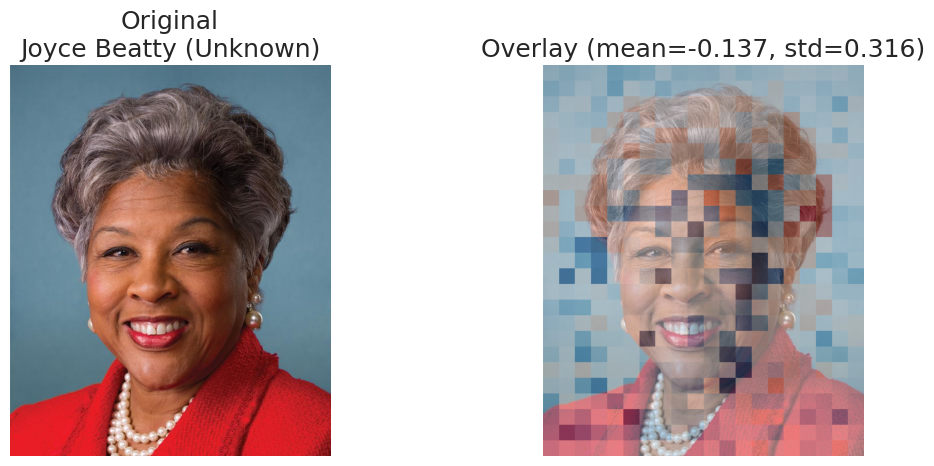

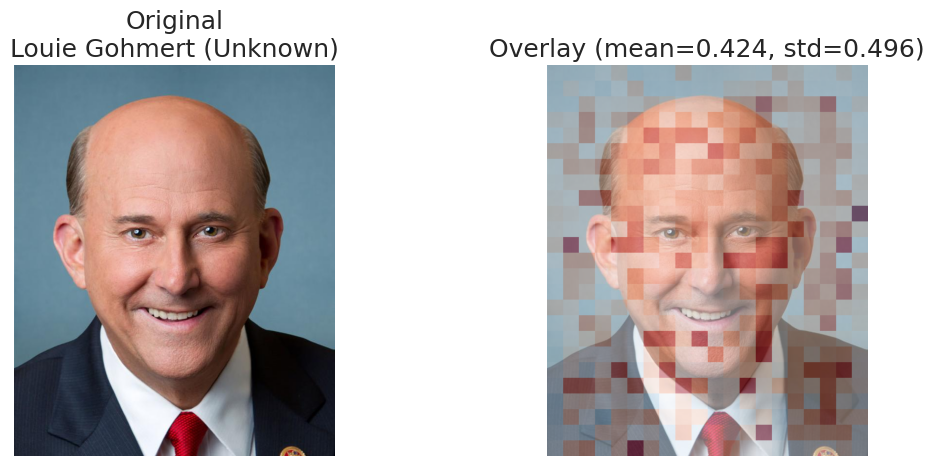

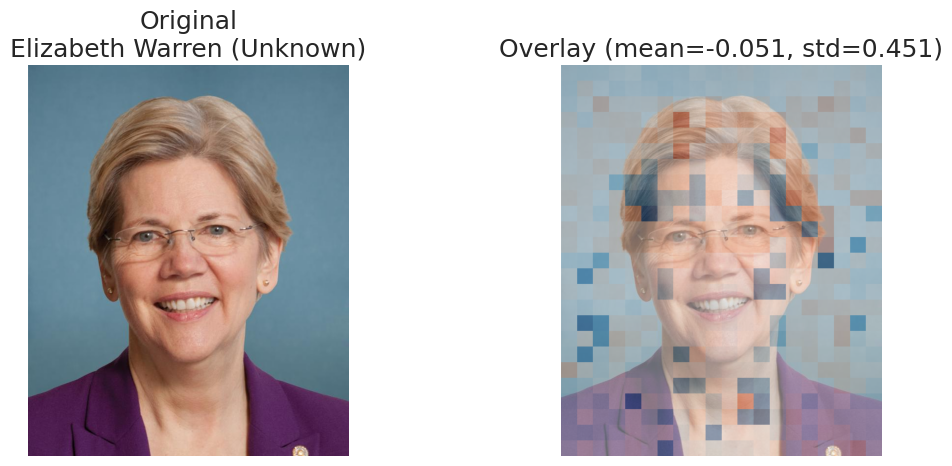

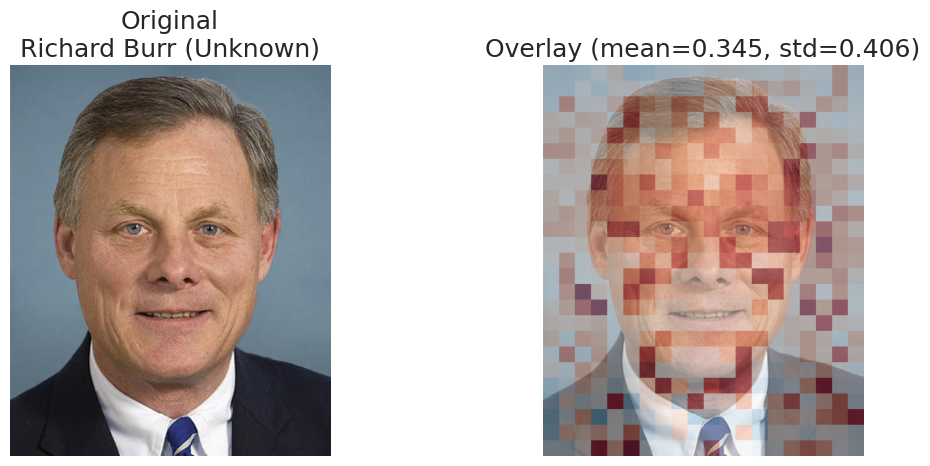

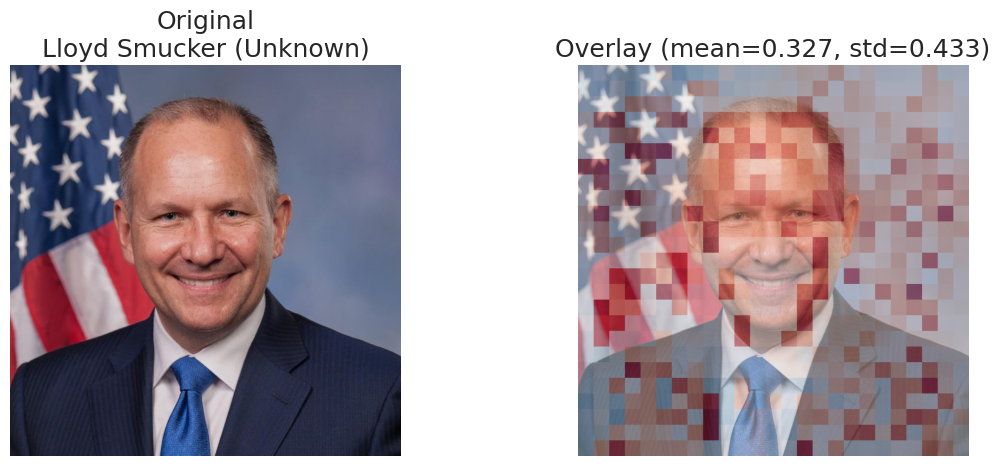

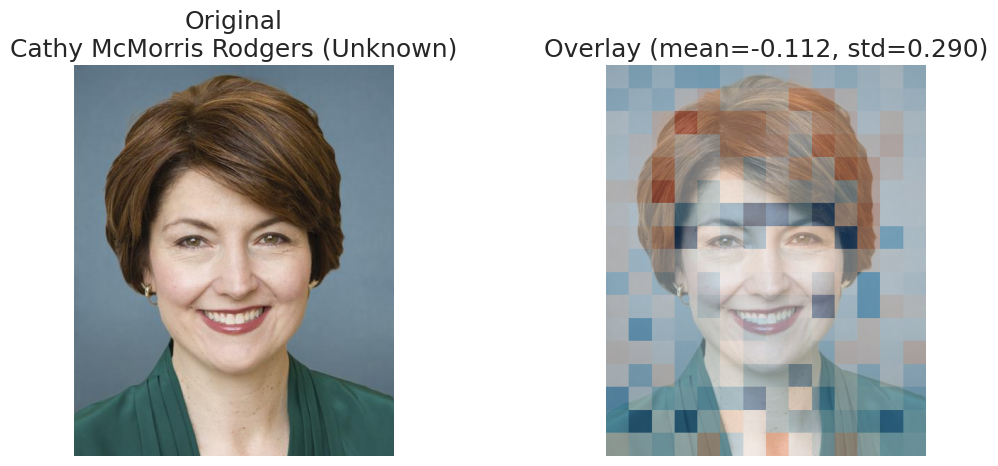

,party,n_images,mean_of_mean,median_of_mean,std_of_mean,mean_abs_score,mean_num_tokens
0,Democrat,284,0.121161,0.125919,0.192509,0.186342,411.947183
1,Republican,262,0.318183,0.335233,0.135508,0.321454,415.923664


/scratch/local/jobs/49505236/ipykernel_2872510/2891776804.py:62: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df_party, x="party", y="mean_image_token_score", order=party_order, palette="Set2", ax=axes[0])
/scratch/local/jobs/49505236/ipykernel_2872510/2891776804.py:68: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(
/scratch/local/jobs/49505236/ipykernel_2872510/2891776804.py:82: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=party_summary, x="party", y="n_images", order=party_order, palette="Set2", ax=axes[2])


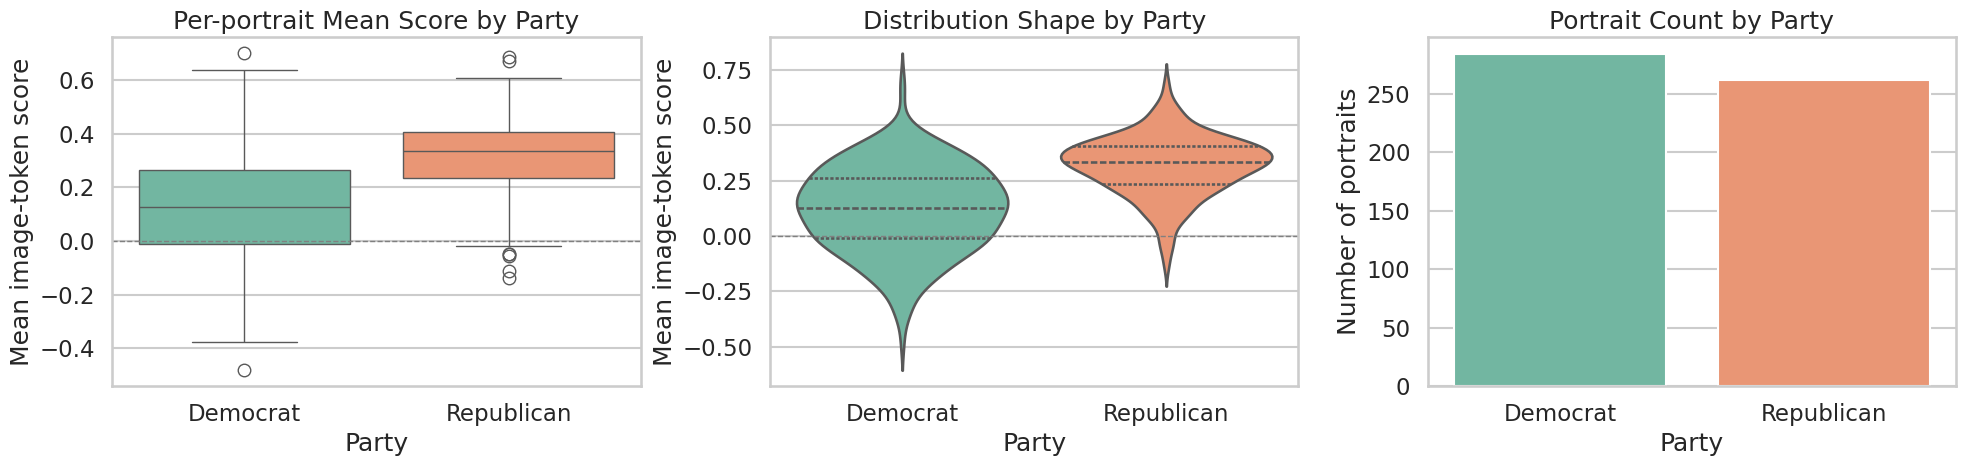

,party,q05,q25,q50,q75,q95
0,Democrat,-0.201047,-0.010538,0.125919,0.262832,0.406626
1,Republican,0.087520,0.235469,0.335233,0.404701,0.531500


,metric,value
0,n_democrat,2.840000e+02
1,n_republican,2.620000e+02
2,mean_diff_rep_minus_dem,1.970214e-01
3,mean_diff_bootstrap_ci_low,1.707234e-01
4,mean_diff_bootstrap_ci_high,2.245236e-01
5,welch_t_stat,-1.391144e+01
6,welch_t_pvalue,1.609090e-37
7,mannwhitney_u_stat,1.489100e+04
8,mannwhitney_u_pvalue,8.760670e-34
9,cohens_d,1.175558e+00


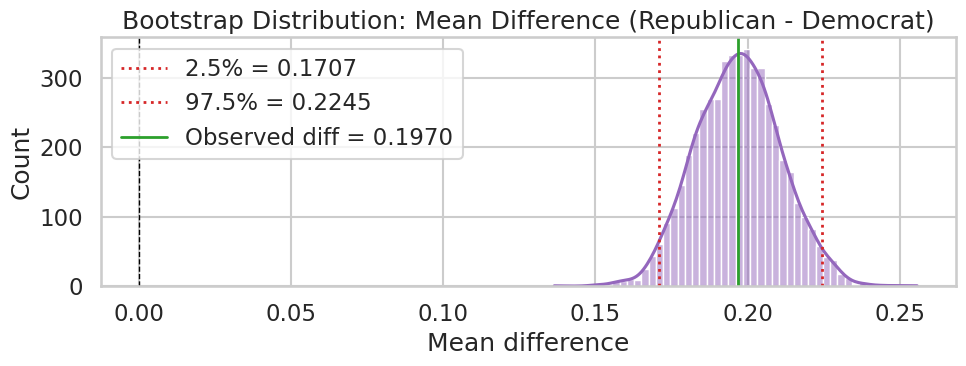

,party,n,pearson_r,spearman_rho
0,Democrat,284,0.364484,0.358627
1,Other (328),4,0.924593,1.000000
2,Republican,262,0.177240,0.154698


Overall Pearson r: 0.5556
Overall Spearman rho: 0.5668


,metric,value
0,member_level_n,548.000000
1,member_level_pearson_r,0.554551
2,member_level_spearman_rho,0.566925


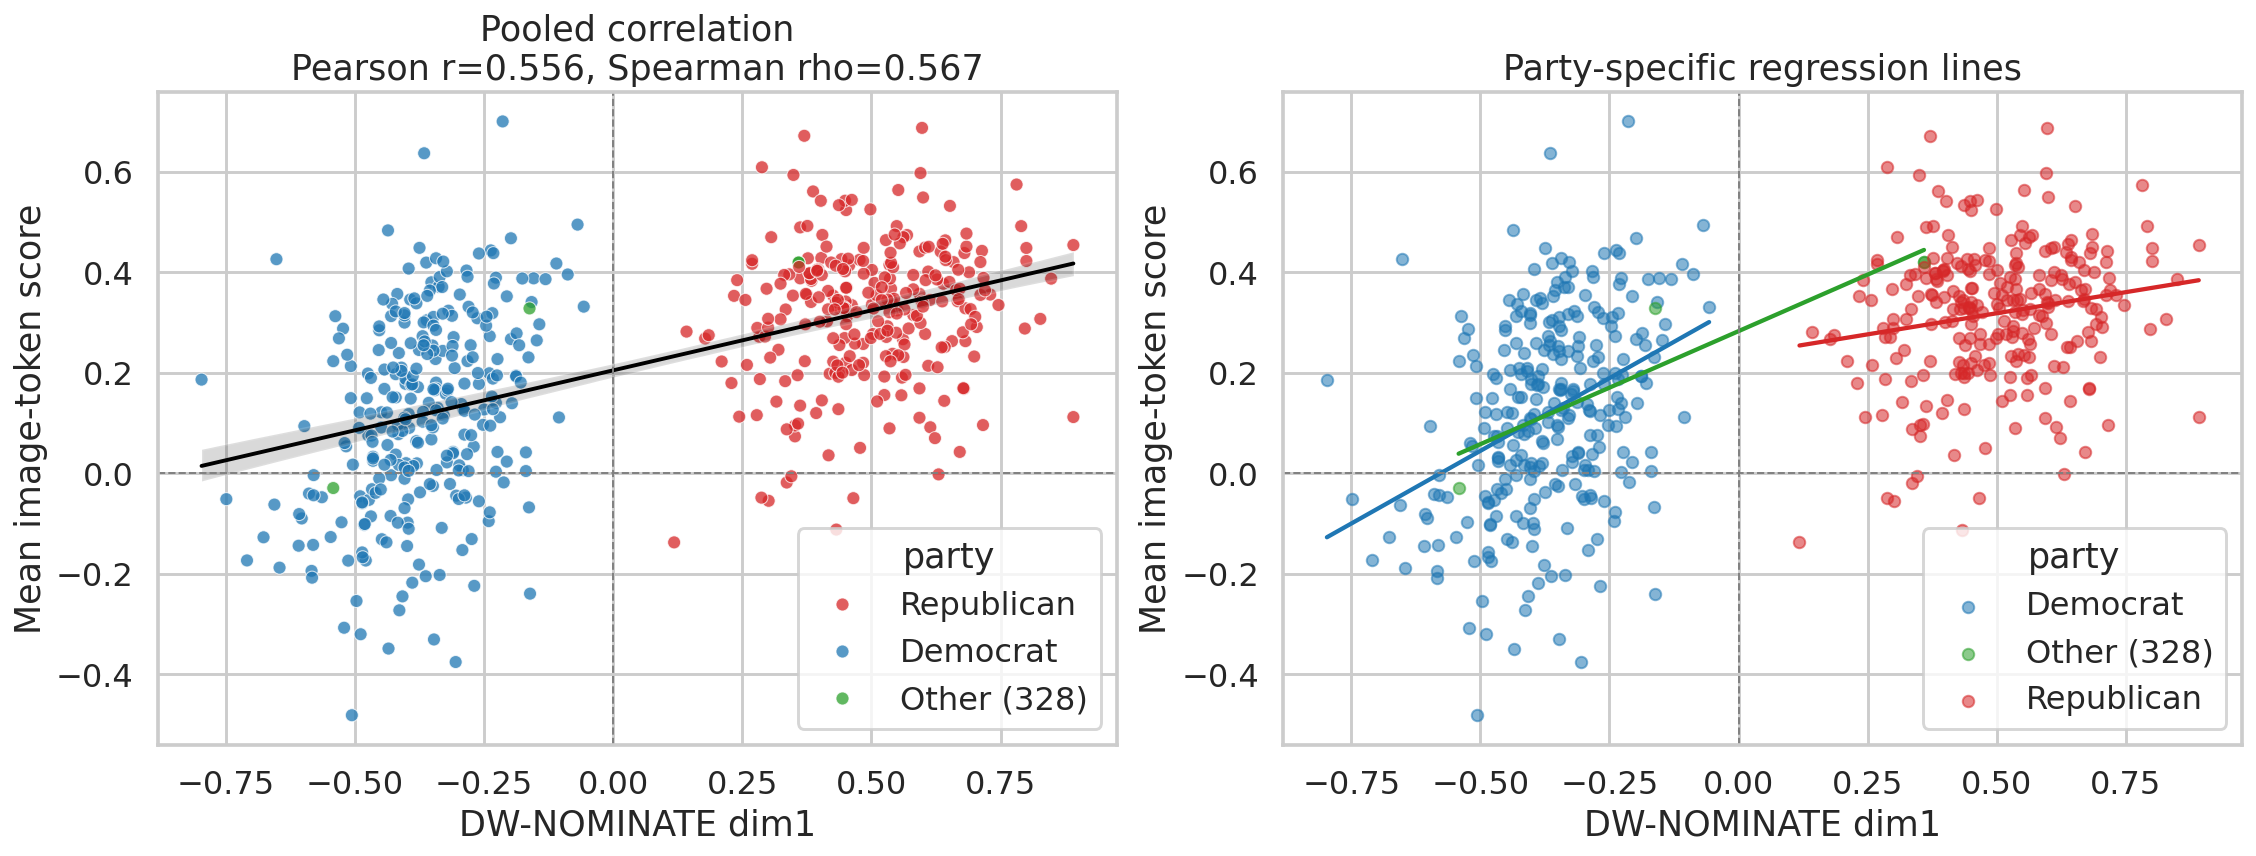

,bioguide,party,nominate_dim1,n_images,mean_image_score,std_image_score
0,V000133,Republican,0.380,2,0.397869,0.0
1,A000367,Other (328),0.359,2,0.419326,0.0
2,N000181,Republican,0.450,1,0.219832,NaN
3,N000188,Democrat,-0.421,1,0.321985,NaN
4,N000189,Republican,0.316,1,0.142575,NaN
5,N000190,Republican,0.848,1,0.387136,NaN
6,N000191,Democrat,-0.396,1,0.118069,NaN
7,O000168,Republican,0.548,1,0.279572,NaN
8,O000171,Democrat,-0.198,1,0.266926,NaN
9,O000173,Democrat,-0.298,1,0.015808,NaN


In [8]:
def run_all(
    ridge_prefix,
    model_family="qwen3_vl",
    dataset="congress",
    probe_name="headwise_linear",
    n_heatmap=6,
    seed=7,
):
    """
    Run full analysis on congress token scoring results.
    
    Args:
        ridge_prefix: probe prefix (e.g. "combined_ideology")
        model_family: model identifier (e.g. "qwen3_vl", "gemma4")
        dataset: dataset name (default: "congress")
        probe_name: probe type (default: "headwise_linear")
        n_heatmap: number of heatmap examples to show
        seed: random seed for reproducibility
    """
    print(f"\n{'='*60}")
    print(f"  Model   : {model_family}")
    print(f"  Dataset : {dataset}")
    print(f"  Prefix  : {ridge_prefix}")
    print(f"  Probe   : {probe_name}")
    print(f"{'='*60}\n")

    payload, df_stats = load_outputs(
        ridge_prefix,
        model_family=model_family,
        dataset=dataset,
        probe_name=probe_name,
    )
    
    # Merge congress metadata if available
    if dataset == "congress":
        df_stats = merge_congress_metadata(df_stats)
    
    # Only show heatmaps if we have image_paths (skip for pure text datasets)
    if any(payload['image_paths']):
        show_heatmap_examples(payload, n=n_heatmap, seed=seed)
    
    df_party, party_summary = analyze_party_comparison(df_stats)
    infer_results = analyze_statistical_inference(df_party)
    df_corr, member_agg = analyze_dw_nominate(df_stats)

    return {
        "payload": payload,
        "df_stats": df_stats,
        "df_party": df_party,
        "party_summary": party_summary,
        "infer_results": infer_results,
        "df_corr": df_corr,
        "member_agg": member_agg,
    }


# Example: Load and analyze congress results for combined_ideology with headwise_linear probe
print("Loading congress results from qwen3_vl model with combined_ideology prefix and headwise_linear probe:")
results_congress_hw = run_all(
    ridge_prefix="combined_ideology",
    model_family="qwen3_vl",
    dataset="congress",
    probe_name="headwise_linear",
    n_heatmap=6,
)


In [9]:
def compute_member_level_correlations(
    models=("qwen3_vl", "gemma4"),
    probes=("headwise_linear", "layerwise_linear", "layerwise_rfm"),
    ridge_prefixes=("combined_ideology",),
    dataset="congress",
):
    """
    Compute member-level DW-NOMINATE vs. mean token score correlations
    for all model × probe × ridge_prefix combinations.
    
    Returns a DataFrame with one row per model/probe/ridge_prefix combination showing
    Pearson and Spearman correlations.
    """
    results = []
    
    for ridge_prefix in ridge_prefixes:
        for model_family in models:
            for probe_name in probes:
                try:
                    # Load the data
                    payload, df_stats = load_outputs(
                        ridge_prefix,
                        model_family=model_family,
                        dataset=dataset,
                        probe_name=probe_name,
                    )
                    
                    # Merge metadata for congress data
                    if dataset == "congress":
                        df_stats = merge_congress_metadata(df_stats)
                    
                    # Filter to records with both nominate_dim1 and scores
                    df_corr = df_stats.dropna(subset=["nominate_dim1", "image_mean"]).copy()
                    if "mean_image_token_score" not in df_corr.columns:
                        df_corr["mean_image_token_score"] = df_corr["image_mean"]
                    if "mean_abs_image_token_score" not in df_corr.columns:
                        df_corr["mean_abs_image_token_score"] = df_corr["image_mean"].abs()
                    
                    if len(df_corr) < 3:
                        print(f"  {ridge_prefix}/{model_family}/{probe_name}: Too few records ({len(df_corr)}), skipping")
                        continue
                    
                    # Aggregate to member level
                    member_agg = (
                        df_corr.groupby(["bioguide", "party", "nominate_dim1"], as_index=False)
                        .agg(
                            n_images=("mean_image_token_score", "size"),
                            mean_score=("mean_image_token_score", "mean"),
                        )
                    )
                    
                    if len(member_agg) < 3:
                        print(f"  {ridge_prefix}/{model_family}/{probe_name}: Too few members ({len(member_agg)}), skipping")
                        continue
                    
                    # Compute correlations
                    pearson_r, pearson_p = scipy_stats.pearsonr(member_agg["nominate_dim1"], member_agg["mean_score"])
                    spearman_rho, spearman_p = scipy_stats.spearmanr(member_agg["nominate_dim1"], member_agg["mean_score"])
                    
                    results.append({
                        "ridge_prefix": ridge_prefix,
                        "model": model_family,
                        "probe": probe_name,
                        "n_members": int(len(member_agg)),
                        "n_images": int(member_agg["n_images"].sum()),
                        "pearson_r": float(pearson_r),
                        "pearson_p": float(pearson_p),
                        "spearman_rho": float(spearman_rho),
                        "spearman_p": float(spearman_p),
                    })
                    
                    print(f"  {ridge_prefix}/{model_family}/{probe_name}: r={pearson_r:.4f}, rho={spearman_rho:.4f}, n={len(member_agg)}")
                    
                except FileNotFoundError as e:
                    print(f"  {ridge_prefix}/{model_family}/{probe_name}: Data not found, skipping")
                except Exception as e:
                    print(f"  {ridge_prefix}/{model_family}/{probe_name}: Error - {str(e)}")
    
    df_results = pd.DataFrame(results)
    return df_results


# Generate member-level correlation table across all models, probes, and ridge prefixes
print("Computing member-level DW-NOMINATE correlations for all model/probe/ridge-prefix combinations...")
print("(This loads each combination, so may take a moment)\n")
correlation_table = compute_member_level_correlations(
    models=("qwen3_vl", "gemma4"),
    probes=("headwise_linear", "layerwise_linear", "layerwise_rfm"),
    ridge_prefixes=("textual_ideology", "combined_ideology",),
    dataset="congress",
)

print("\n" + "="*80)
print("MEMBER-LEVEL DW-NOMINATE vs. MEAN IMAGE TOKEN SCORE CORRELATIONS")
print("="*80)
display(correlation_table)

# Summary statistics
print("\nSummary by ridge prefix:")
if not correlation_table.empty:
    for prefix in correlation_table["ridge_prefix"].unique():
        subset = correlation_table[correlation_table["ridge_prefix"] == prefix]
        print(f"\n{prefix}:")
        print(f"  Mean Pearson r: {subset['pearson_r'].mean():.4f}")
        print(f"  Mean Spearman rho: {subset['spearman_rho'].mean():.4f}")
        print(f"  Combinations: {len(subset)}")


Computing member-level DW-NOMINATE correlations for all model/probe/ridge-prefix combinations...
(This loads each combination, so may take a moment)

  textual_ideology/qwen3_vl/headwise_linear: Data not found, skipping
  textual_ideology/qwen3_vl/layerwise_linear: Data not found, skipping
  textual_ideology/qwen3_vl/layerwise_rfm: Data not found, skipping
  textual_ideology/gemma4/headwise_linear: Data not found, skipping
  textual_ideology/gemma4/layerwise_linear: Data not found, skipping
  textual_ideology/gemma4/layerwise_rfm: Data not found, skipping
Loaded image token scores : results/token_scoring/qwen3_vl/congress/prompt_image_token_scores_combined_ideology_headwise_linear.pt
Loaded stats CSV          : results/token_scoring/qwen3_vl/congress/prompt_token_stats_combined_ideology_headwise_linear.csv
Num records               : 550
Records with images       : 550

Metadata:


model_path                  /home/tzhang3/jevans/models/Qwen3-VL-8B-Instruct
model_family                                                        qwen3-vl
mode                                                                  vision
probe                                                        headwise_linear
prefix                                                     combined_ideology
top_k                                                                     16
data                                   data/probes/congress_score_data.jsonl
num_records                                                              550
num_records_with_images                                                  550
image_token_ids                                                     [151655]
probe_weights_path         results/probes/qwen3-vl-8b-instruct/combined_i...
probe_scores_path          results/probes/qwen3-vl-8b-instruct/combined_i...
probe_metadata_path        results/probes/qwen3-vl-8b-instruct/combined_i...


Stats sample:


,record_id,record_name,image_path,image_h,image_w,grid_h,grid_w,num_image_tokens,expected_image_tokens,image_token_mismatch,...,image_mean,image_median,image_min,image_max,image_std,all_mean,all_median,all_min,all_max,all_std
0,congress_R000575,Mike Rogers,results/token_scoring/qwen3_vl/congress/_resiz...,553,452,17,14,238,238,0,...,0.427642,0.376880,-0.491718,1.669692,0.480268,0.423665,0.379516,-0.491718,1.669692,0.479483
1,congress_S001185,Terri A. Sewell,results/token_scoring/qwen3_vl/congress/_resiz...,553,452,17,14,238,238,0,...,-0.098132,-0.090295,-0.860635,0.556930,0.276904,-0.083095,-0.070735,-0.860635,0.575481,0.280301
2,congress_R000591,Martha Roby,results/token_scoring/qwen3_vl/congress/_resiz...,800,655,25,20,500,500,0,...,0.134562,0.127620,-0.699318,1.056999,0.299059,0.140145,0.129854,-0.699318,1.056999,0.303287
3,congress_B001274,Mo Brooks,results/token_scoring/qwen3_vl/congress/_resiz...,553,452,17,14,238,238,0,...,0.531849,0.470206,-0.460906,2.044572,0.539328,0.524888,0.468161,-0.460906,2.044572,0.540067
4,congress_B001289,Bradley Byrne,results/token_scoring/qwen3_vl/congress/_resiz...,324,289,10,9,90,90,0,...,0.401233,0.314327,-0.348687,1.221393,0.415722,0.389035,0.300341,-0.355215,1.374400,0.423652


  combined_ideology/qwen3_vl/headwise_linear: r=0.5546, rho=0.5669, n=548
Loaded image token scores : results/token_scoring/qwen3_vl/congress/prompt_image_token_scores_combined_ideology_layerwise_linear.pt
Loaded stats CSV          : results/token_scoring/qwen3_vl/congress/prompt_token_stats_combined_ideology_layerwise_linear.csv
Num records               : 550
Records with images       : 550

Metadata:


...


Stats sample:


,record_id,record_name,image_path,image_h,image_w,grid_h,grid_w,num_image_tokens,expected_image_tokens,image_token_mismatch,...,image_mean,image_median,image_min,image_max,image_std,all_mean,all_median,all_min,all_max,all_std
0,congress_R000575,Mike Rogers,results/token_scoring/gemma4/congress/_resized...,553,452,18,15,270,270,0,...,0.591342,0.580216,-0.539333,1.723041,0.471416,0.597942,0.588237,-0.539333,1.760060,0.477095
1,congress_S001185,Terri A. Sewell,results/token_scoring/gemma4/congress/_resized...,553,452,18,15,270,270,0,...,0.075516,0.050606,-0.844466,1.424890,0.406451,0.100829,0.073284,-0.844466,1.424890,0.414113
2,congress_R000591,Martha Roby,results/token_scoring/gemma4/congress/_resized...,800,655,18,15,270,270,0,...,0.260463,0.263828,-0.948388,1.298134,0.395482,0.277957,0.291093,-0.948388,1.298134,0.398321
3,congress_B001274,Mo Brooks,results/token_scoring/gemma4/congress/_resized...,553,452,18,15,270,270,0,...,0.593282,0.532366,-0.445449,1.972589,0.496125,0.597965,0.553342,-0.445449,1.972589,0.494628
4,congress_B001289,Bradley Byrne,results/token_scoring/gemma4/congress/_resized...,324,289,17,15,255,255,0,...,0.462434,0.453769,-0.459798,1.586614,0.408204,0.479256,0.480919,-0.459798,1.586614,0.418093


  combined_ideology/gemma4/layerwise_rfm: r=0.5370, rho=0.5472, n=548

MEMBER-LEVEL DW-NOMINATE vs. MEAN IMAGE TOKEN SCORE CORRELATIONS


,ridge_prefix,model,probe,n_members,n_images,pearson_r,pearson_p,spearman_rho,spearman_p
0,combined_ideology,qwen3_vl,headwise_linear,548,550,0.554551,1.649788e-45,0.566925,6.425900e-48
1,combined_ideology,qwen3_vl,layerwise_linear,548,550,0.540234,7.629216e-43,0.512376,5.196579e-38
2,combined_ideology,qwen3_vl,layerwise_rfm,548,550,0.554497,1.689162e-45,0.567569,4.782439e-48
3,combined_ideology,gemma4,headwise_linear,548,550,0.594258,1.283554e-53,0.596799,3.553020e-54
4,combined_ideology,gemma4,layerwise_linear,548,550,0.496851,1.665277e-35,0.469365,2.262583e-31
5,combined_ideology,gemma4,layerwise_rfm,548,550,0.537014,2.912170e-42,0.547183,4.026603e-44



Summary by ridge prefix:

combined_ideology:
  Mean Pearson r: 0.5462
  Mean Spearman rho: 0.5434
  Combinations: 6


In [14]:
def identify_outliers(df_corr, member_agg, n_outliers=10, metric='residual'):
    """
    Identify members whose DW-NOMINATE score and mean token score don't correspond.
    
    Args:
        df_corr: Individual record dataframe with nominate_dim1 and mean_image_token_score
        member_agg: Member-level aggregated dataframe
        n_outliers: Number of outliers to identify (top n by absolute residual or correlation deviation)
        metric: 'residual' for absolute deviation from regression line, or 'abs_score' for high absolute scores
    
    Returns:
        DataFrame with outlier members, sorted by outlier magnitude
    """
    from sklearn.linear_model import LinearRegression
    
    # Fit linear regression at member level
    X = member_agg[["nominate_dim1"]].values
    y = member_agg[["mean_image_score"]].values
    
    model = LinearRegression()
    model.fit(X, y)
    predicted = model.predict(X).flatten()
    residuals = y.flatten() - predicted
    
    member_agg_copy = member_agg.copy()
    member_agg_copy['predicted_score'] = predicted
    member_agg_copy['residual'] = residuals
    member_agg_copy['abs_residual'] = np.abs(residuals)
    
    if metric == 'residual':
        outliers = member_agg_copy.nlargest(n_outliers, 'abs_residual')
    else:
        outliers = member_agg_copy.nlargest(n_outliers, 'mean_image_score')
    
    return outliers.reset_index(drop=True)


def get_member_records(df_corr, bioguide):
    """Get all image records for a specific member (by bioguide)."""
    return df_corr[df_corr["bioguide"] == bioguide].reset_index(drop=True)


def save_outlier_heatmaps(
    payload,
    df_corr,
    outliers,
    output_dir="results/outlier_heatmaps",
    dpi=150,
):
    """
    Save heatmap visualizations for outlier members.
    
    Args:
        payload: Token scoring payload with image paths and scores
        df_corr: Individual record dataframe
        outliers: DataFrame of outlier members (from identify_outliers)
        output_dir: Directory to save visualizations
        dpi: Figure DPI for saved images
    """
    from pathlib import Path
    
    output_path = Path(output_dir)
    output_path.mkdir(parents=True, exist_ok=True)
    
    saved_files = []
    
    for idx, row in outliers.iterrows():
        bioguide = row['bioguide']
        party = row['party']
        nominate_dim1 = row['nominate_dim1']
        mean_score = row['mean_image_score']
        residual = row['residual']
        
        # Get all records for this member
        member_records = get_member_records(df_corr, bioguide)
        
        if len(member_records) == 0:
            print(f"  Skipping {bioguide}: no records found")
            continue
        
        # Create figure with subplots for each image
        n_images = len(member_records)
        n_cols = min(3, n_images)
        n_rows = (n_images + n_cols - 1) // n_cols
        
        fig = plt.figure(figsize=(5*n_cols, 5*n_rows + 1), dpi=dpi)
        fig.suptitle(
            f"{bioguide} ({party}) | DW-NOMINATE: {nominate_dim1:.3f} | "
            f"Mean Token Score: {mean_score:.3f} | Residual: {residual:.3f}",
            fontsize=14,
            fontweight='bold',
            y=0.98
        )
        
        # Find indices in payload for this member's records
        payload_indices = []
        for rec_idx, member_rec in member_records.iterrows():
            record_id = member_rec['record_id']
            if record_id in payload['record_ids']:
                p_idx = payload['record_ids'].index(record_id)
                payload_indices.append(p_idx)
        
        for subplot_idx, p_idx in enumerate(payload_indices[:n_rows*n_cols]):
            ax = fig.add_subplot(n_rows, n_cols, subplot_idx + 1)
            
            image_path = payload["image_paths"][p_idx]
            if not image_path or not Path(image_path).exists():
                ax.text(0.5, 0.5, "Image not found", ha='center', va='center', transform=ax.transAxes)
                ax.axis('off')
                continue
            
            grid_h, grid_w = payload["grid_hw"][p_idx].tolist()
            flat_scores = get_image_scores_for_index(payload, p_idx)
            
            if len(flat_scores) != grid_h * grid_w:
                ax.text(0.5, 0.5, "Score mismatch", ha='center', va='center', transform=ax.transAxes)
                ax.axis('off')
                continue
            
            heat = flat_scores.reshape(grid_h, grid_w)
            img = Image.open(image_path).convert("RGB")
            lim = max(1e-6, float(np.max(np.abs(heat))))
            over = overlay_heatmap_on_image(img, heat, alpha=0.45, cmap="RdBu_r", vmin=-lim, vmax=lim)
            
            ax.imshow(over)
            ax.set_title(
                f"Score: {float(np.mean(flat_scores)):.3f}",
                fontsize=10
            )
            ax.axis('off')
        
        # Hide unused subplots
        for subplot_idx in range(len(payload_indices), n_rows * n_cols):
            ax = fig.add_subplot(n_rows, n_cols, subplot_idx + 1)
            ax.axis('off')
        
        plt.tight_layout()
        
        # Save figure
        filename = f"{bioguide}_{party}_{nominate_dim1:.3f}_{mean_score:.3f}.png"
        filepath = output_path / filename
        fig.savefig(filepath, dpi=dpi, bbox_inches='tight')
        plt.close(fig)
        
        saved_files.append({
            'filename': str(filepath),
            'bioguide': bioguide,
            'party': party,
            'nominate_dim1': nominate_dim1,
            'mean_score': mean_score,
            'residual': residual,
            'n_images': len(payload_indices),
        })
        
        print(f"  Saved: {filename}")
    
    return pd.DataFrame(saved_files)

In [17]:
# Identify and visualize outliers
# Using the congress results from combined_ideology + headwise_linear probe

print("Identifying outliers: Members whose DW-NOMINATE scores don't align with token scores\n")

# Get the data from our previous analysis
df_corr_for_outliers = results_congress_hw["df_corr"]
member_agg_for_outliers = results_congress_hw["member_agg"]
payload_for_outliers = results_congress_hw["payload"]

# Identify top outliers (both positive and negative residuals)
outliers_df = identify_outliers(
    df_corr_for_outliers, 
    member_agg_for_outliers,
    n_outliers=12,
    metric='residual'
)

print("Top outliers (by absolute residual from DW-NOMINATE vs token score regression):\n")
display(outliers_df[['bioguide', 'party', 'nominate_dim1', 'mean_image_score', 'residual', 'n_images']])

print("\n" + "="*80)
print("Saving heatmap visualizations for outliers...")
print("="*80 + "\n")

# Save heatmap visualizations for these outliers
saved_summary = save_outlier_heatmaps(
    payload_for_outliers,
    df_corr_for_outliers,
    outliers_df,
    output_dir="results/outlier_heatmaps",
    dpi=150,
)

print("\n" + "="*80)
print(f"Saved {len(saved_summary)} outlier visualizations to results/outlier_heatmaps/")
print("="*80)
display(saved_summary)


Identifying outliers: Members whose DW-NOMINATE scores don't align with token scores

Top outliers (by absolute residual from DW-NOMINATE vs token score regression):



,bioguide,party,nominate_dim1,mean_image_score,residual,n_images
0,B001300,Democrat,-0.506,-0.481216,-0.565213,1
1,T000464,Democrat,-0.214,0.699849,0.546393,1
2,M000639,Democrat,-0.366,0.636516,0.519216,1
3,C000127,Democrat,-0.305,-0.375401,-0.507212,1
4,B001303,Democrat,-0.347,-0.330529,-0.452348,1
5,M001163,Democrat,-0.435,-0.348620,-0.449506,1
6,M001159,Republican,0.432,-0.111958,-0.419082,1
7,C001080,Democrat,-0.489,-0.320152,-0.408193,1
8,M001202,Democrat,-0.161,-0.239390,-0.405454,1
9,R000606,Democrat,-0.521,-0.307220,-0.387649,1



Saving heatmap visualizations for outliers...

  Saved: B001300_Democrat_-0.506_-0.481.png
  Saved: T000464_Democrat_-0.214_0.700.png
  Saved: M000639_Democrat_-0.366_0.637.png
  Saved: C000127_Democrat_-0.305_-0.375.png
  Saved: B001303_Democrat_-0.347_-0.331.png
  Saved: M001163_Democrat_-0.435_-0.349.png
  Saved: M001159_Republican_0.432_-0.112.png
  Saved: C001080_Democrat_-0.489_-0.320.png
  Saved: M001202_Democrat_-0.161_-0.239.png
  Saved: R000606_Democrat_-0.521_-0.307.png
  Saved: B001277_Democrat_-0.436_0.483.png
  Saved: G000359_Republican_0.370_0.671.png

Saved 12 outlier visualizations to results/outlier_heatmaps/


,filename,bioguide,party,nominate_dim1,mean_score,residual,n_images
0,results/outlier_heatmaps/B001300_Democrat_-0.5...,B001300,Democrat,-0.506,-0.481216,-0.565213,1
1,results/outlier_heatmaps/T000464_Democrat_-0.2...,T000464,Democrat,-0.214,0.699849,0.546393,1
2,results/outlier_heatmaps/M000639_Democrat_-0.3...,M000639,Democrat,-0.366,0.636516,0.519216,1
3,results/outlier_heatmaps/C000127_Democrat_-0.3...,C000127,Democrat,-0.305,-0.375401,-0.507212,1
4,results/outlier_heatmaps/B001303_Democrat_-0.3...,B001303,Democrat,-0.347,-0.330529,-0.452348,1
5,results/outlier_heatmaps/M001163_Democrat_-0.4...,M001163,Democrat,-0.435,-0.348620,-0.449506,1
6,results/outlier_heatmaps/M001159_Republican_0....,M001159,Republican,0.432,-0.111958,-0.419082,1
7,results/outlier_heatmaps/C001080_Democrat_-0.4...,C001080,Democrat,-0.489,-0.320152,-0.408193,1
8,results/outlier_heatmaps/M001202_Democrat_-0.1...,M001202,Democrat,-0.161,-0.239390,-0.405454,1
9,results/outlier_heatmaps/R000606_Democrat_-0.5...,R000606,Democrat,-0.521,-0.307220,-0.387649,1


In [23]:
# Alternative filtering: Select by ideology + extreme score mismatch
# For DW < 0 (Democrats): top 20 with highest token scores (most right-looking)
# For DW > 0 (Republicans): bottom 20 with lowest token scores (most left-looking)

print("Identifying mismatches by ideology direction:")
print("  Democrats (DW-NOMINATE < 0) with HIGHEST image token scores")
print("  Republicans (DW-NOMINATE > 0) with LOWEST image token scores\n")

from pathlib import Path

member_agg_analysis = member_agg_for_outliers.copy()

# Split by ideology
left_leaning = member_agg_analysis[member_agg_analysis["nominate_dim1"] < 0].copy()
right_leaning = member_agg_analysis[member_agg_analysis["nominate_dim1"] > 0].copy()

# Select outliers: left with highest scores, right with lowest scores
left_outliers = left_leaning.nlargest(20, "mean_image_score").reset_index(drop=True)
right_outliers = right_leaning.nsmallest(20, "mean_image_score").reset_index(drop=True)

print(f"Selected {len(left_outliers)} left-leaning politicians with highest scores")
print(f"Selected {len(right_outliers)} right-leaning politicians with lowest scores")
print(f"Total: {len(left_outliers) + len(right_outliers)} politicians\n")

print("Left-leaning (DW < 0) with highest token scores:")
display(left_outliers[['bioguide', 'party', 'nominate_dim1', 'mean_image_score', 'n_images']].head(10))

print("\nRight-leaning (DW > 0) with lowest token scores:")
display(right_outliers[['bioguide', 'party', 'nominate_dim1', 'mean_image_score', 'n_images']].head(10))

print("\n" + "="*80)
print("Saving heatmap visualizations...")
print("="*80 + "\n")

# Save visualizations for both groups
output_path = Path("results/outlier_heatmaps_by_direction")
output_path.mkdir(parents=True, exist_ok=True)
saved_files = []

for group_name, group_df in [("left", left_outliers), ("right", right_outliers)]:
    for idx, row in group_df.iterrows():
        bioguide = row['bioguide']
        party = row['party']
        nominate_dim1 = row['nominate_dim1']
        mean_score = row['mean_image_score']
        
        # Get all records for this member
        member_records = get_member_records(df_corr_for_outliers, bioguide)
        
        if len(member_records) == 0:
            print(f"  Skipping {bioguide}: no records found")
            continue
        
        # Create figure with subplots for each image
        n_images = len(member_records)
        n_cols = min(3, n_images)
        n_rows = (n_images + n_cols - 1) // n_cols
        
        fig = plt.figure(figsize=(5*n_cols, 5*n_rows + 1), dpi=150)
        fig.suptitle(
            f"{bioguide} ({party}) | DW-NOMINATE: {nominate_dim1:.3f} | "
            f"Mean Token Score: {mean_score:.3f}",
            fontsize=14,
            fontweight='bold',
            y=0.98
        )
        
        # Find indices in payload for this member's records
        payload_indices = []
        for rec_idx, member_rec in member_records.iterrows():
            record_id = member_rec['record_id']
            if record_id in payload_for_outliers['record_ids']:
                p_idx = payload_for_outliers['record_ids'].index(record_id)
                payload_indices.append(p_idx)
        
        for subplot_idx, p_idx in enumerate(payload_indices[:n_rows*n_cols]):
            ax = fig.add_subplot(n_rows, n_cols, subplot_idx + 1)
            
            image_path = payload_for_outliers["image_paths"][p_idx]
            if not image_path or not Path(image_path).exists():
                ax.text(0.5, 0.5, "Image not found", ha='center', va='center', transform=ax.transAxes)
                ax.axis('off')
                continue
            
            grid_h, grid_w = payload_for_outliers["grid_hw"][p_idx].tolist()
            flat_scores = get_image_scores_for_index(payload_for_outliers, p_idx)
            
            if len(flat_scores) != grid_h * grid_w:
                ax.text(0.5, 0.5, "Score mismatch", ha='center', va='center', transform=ax.transAxes)
                ax.axis('off')
                continue
            
            heat = flat_scores.reshape(grid_h, grid_w)
            img = Image.open(image_path).convert("RGB")
            lim = max(1e-6, float(np.max(np.abs(heat))))
            over = overlay_heatmap_on_image(img, heat, alpha=0.45, cmap="RdBu_r", vmin=-lim, vmax=lim)
            
            ax.imshow(over)
            ax.set_title(f"Score: {float(np.mean(flat_scores)):.3f}", fontsize=10)
            ax.axis('off')
        
        # Hide unused subplots
        for subplot_idx in range(len(payload_indices), n_rows * n_cols):
            ax = fig.add_subplot(n_rows, n_cols, subplot_idx + 1)
            ax.axis('off')
        
        plt.tight_layout()
        
        # Save figure
        filename = f"{bioguide}_{party}_{nominate_dim1:.3f}_{mean_score:.3f}.png"
        filepath = output_path / filename
        fig.savefig(filepath, dpi=150, bbox_inches='tight')
        plt.close(fig)
        
        saved_files.append({
            'filename': str(filepath),
            'bioguide': bioguide,
            'party': party,
            'nominate_dim1': nominate_dim1,
            'mean_score': mean_score,
            'group': group_name,
            'n_images': len(payload_indices),
        })
        
        print(f"  Saved: {filename}")

print("\n" + "="*80)
print(f"Saved {len(saved_files)} visualizations to results/outlier_heatmaps_by_direction/")
print("="*80)
saved_df = pd.DataFrame(saved_files)
display(saved_df[['bioguide', 'party', 'nominate_dim1', 'mean_score', 'group']])


Identifying mismatches by ideology direction:
  Democrats (DW-NOMINATE < 0) with HIGHEST image token scores
  Republicans (DW-NOMINATE > 0) with LOWEST image token scores

Selected 20 left-leaning politicians with highest scores
Selected 20 right-leaning politicians with lowest scores
Total: 40 politicians

Left-leaning (DW < 0) with highest token scores:


,bioguide,party,nominate_dim1,mean_image_score,n_images
0,T000464,Democrat,-0.214,0.699849,1
1,M000639,Democrat,-0.366,0.636516,1
2,M001209,Democrat,-0.069,0.494628,1
3,B001277,Democrat,-0.436,0.483079,1
4,C001055,Democrat,-0.198,0.467430,1
5,L000559,Democrat,-0.375,0.448374,1
6,P000614,Democrat,-0.237,0.443308,1
7,C001088,Democrat,-0.232,0.437843,1
8,K000188,Democrat,-0.260,0.437187,1
9,C001124,Democrat,-0.343,0.427684,1



Right-leaning (DW > 0) with lowest token scores:


,bioguide,party,nominate_dim1,mean_image_score,n_images
0,C001035,Republican,0.118,-0.137439,1
1,M001159,Republican,0.432,-0.111958,1
2,S001196,Republican,0.301,-0.054727,1
3,F000463,Republican,0.465,-0.049498,1
4,H001073,Republican,0.287,-0.048443,1
5,R000600,Republican,0.336,-0.018356,1
6,M001197,Republican,0.345,-0.005929,1
7,S001184,Republican,0.630,-0.002192,1
8,H001074,Republican,0.417,0.035738,1
9,H001052,Republican,0.671,0.042494,1



Saving heatmap visualizations...

  Saved: T000464_Democrat_-0.214_0.700.png
  Saved: M000639_Democrat_-0.366_0.637.png
  Saved: M001209_Democrat_-0.069_0.495.png
  Saved: B001277_Democrat_-0.436_0.483.png
  Saved: C001055_Democrat_-0.198_0.467.png
  Saved: L000559_Democrat_-0.375_0.448.png
  Saved: P000614_Democrat_-0.237_0.443.png
  Saved: C001088_Democrat_-0.232_0.438.png
  Saved: K000188_Democrat_-0.260_0.437.png
  Saved: C001124_Democrat_-0.343_0.428.png
  Saved: C001117_Democrat_-0.652_0.426.png
  Saved: M001206_Democrat_-0.329_0.421.png
  Saved: S001193_Democrat_-0.362_0.419.png
  Saved: G000592_Democrat_-0.110_0.417.png
  Saved: L000557_Democrat_-0.396_0.407.png
  Saved: S001211_Democrat_-0.284_0.403.png
  Saved: T000483_Democrat_-0.322_0.402.png
  Saved: J000300_Democrat_-0.088_0.395.png
  Saved: M001196_Democrat_-0.282_0.391.png
  Saved: R000616_Democrat_-0.336_0.390.png
  Saved: C001035_Republican_0.118_-0.137.png
  Saved: M001159_Republican_0.432_-0.112.png
  Saved: S00119

,bioguide,party,nominate_dim1,mean_score,group
0,T000464,Democrat,-0.214,0.699849,left
1,M000639,Democrat,-0.366,0.636516,left
2,M001209,Democrat,-0.069,0.494628,left
3,B001277,Democrat,-0.436,0.483079,left
4,C001055,Democrat,-0.198,0.467430,left
5,L000559,Democrat,-0.375,0.448374,left
6,P000614,Democrat,-0.237,0.443308,left
7,C001088,Democrat,-0.232,0.437843,left
8,K000188,Democrat,-0.260,0.437187,left
9,C001124,Democrat,-0.343,0.427684,left
